In [1]:
import math
from pathlib import Path


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset_path = Path("../dataset")
accounts_path = dataset_path / "HI-Small_accounts.csv"
transactions_path = dataset_path / "HI-Small_Trans.csv"
print(f"{accounts_path=}")
print(f"{transactions_path=}")

accounts_path=PosixPath('../dataset/HI-Small_accounts.csv')
transactions_path=PosixPath('../dataset/HI-Small_Trans.csv')


# Understanding Accounts

In [3]:
accounts = pd.read_csv(accounts_path)
print(f"{accounts.shape=}")
accounts.head()

accounts.shape=(518581, 5)


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


In [4]:
accounts.info()

<class 'pandas.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Bank Name       518581 non-null  str  
 1   Bank ID         518581 non-null  int64
 2   Account Number  518581 non-null  str  
 3   Entity ID       518581 non-null  str  
 4   Entity Name     518581 non-null  str  
dtypes: int64(1), str(4)
memory usage: 19.8 MB


In [5]:
print(f"accounts duplicated rows: {accounts.duplicated().sum()}")

accounts duplicated rows: 0


In [6]:
for column in accounts.columns:
    print(accounts[column].value_counts())
    print("-" * 50)

Bank Name
National Bank of Laramie       3797
National Bank of the East      3663
Japan Bank #0                  3051
Arbor Savings Bank             2894
National Bank of Pittsburgh    2683
                               ... 
Brazil Bank #218                  1
Greece Bank #2917                 1
Brazil Bank #411                  1
Japan Bank #701                   1
UK Bank #483                      1
Name: count, Length: 20053, dtype: int64
--------------------------------------------------
Bank ID
12        3161
10        3108
15        3051
220       2530
1         2172
          ... 
341480       1
349913       1
328347       1
353301       1
352697       1
Name: count, Length: 30470, dtype: int64
--------------------------------------------------
Account Number
80A7FDE00    2
80A7FD400    2
80FA56340    2
80FA55EF0    2
8135B8200    2
            ..
807886B70    1
81314C870    1
804ED2270    1
801727270    1
804F6D9F0    1
Name: count, Length: 518573, dtype: int64
---------------

- why do some accounts recorded twice?
- what does the number behind the bank name and the entity name mean?

In [7]:
accounts[(accounts['Account Number'].isin(['80A7FDE00', '80A7FD400', '80FA56340']))].sort_values(by='Account Number')

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
62794,Australia Bank #44,28248,80A7FD400,800D28430,Partnership #36506
122088,Australia Bank #47,27755,80A7FD400,800CCD520,Corporation #33736
61324,Australia Bank #44,28248,80A7FDE00,800D15C50,Corporation #34165
124530,Australia Bank #47,27755,80A7FDE00,800D28430,Partnership #36506
149001,Germany Bank #908,138832,80FA56340,8006CF910,Partnership #28810
417905,Italy Bank #97,13858,80FA56340,80087BC70,Corporation #25811


after doing some research it's possible that the same account number exists in different banks if we assume there is no routing code (bank identifider) prefixed the account number

In [8]:
laramie_accounts = accounts.query("`Bank Name` == 'National Bank of Laramie'")
for column in laramie_accounts.columns:
    print(laramie_accounts[column].value_counts())
    print("-" * 50)

Bank Name
National Bank of Laramie    3797
Name: count, dtype: int64
--------------------------------------------------
Bank ID
10        3108
115700     289
15085      257
31223       14
32508       13
31284       10
313535       9
34541        8
313461       7
312991       7
33190        6
316244       6
323568       5
37446        5
322432       5
332894       4
336288       4
336077       4
323656       3
350728       3
331618       3
319045       3
333299       3
325490       3
349157       2
335259       2
348833       2
342595       2
333905       2
338402       2
327726       2
339488       1
352479       1
330985       1
344426       1
Name: count, dtype: int64
--------------------------------------------------
Account Number
803500540    1
8132804C0    1
80D51FBD0    1
80CE80760    1
8114807F0    1
            ..
803FFFB20    1
804F7FBA0    1
800730490    1
80BF60520    1
8035FFA70    1
Name: count, Length: 3797, dtype: int64
--------------------------------------------------

In [9]:
laramie_accounts

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
63,National Bank of Laramie,10,803500540,800AEFF20,Sole Proprietorship #3008
407,National Bank of Laramie,10,8132804C0,800E88400,Partnership #18688
426,National Bank of Laramie,115700,80D51FBD0,8006C4140,Corporation #14273
561,National Bank of Laramie,10,80CE80760,800D84F00,Partnership #36817
700,National Bank of Laramie,10,8114807F0,800DCB2F0,Corporation #13100
...,...,...,...,...,...
518096,National Bank of Laramie,10,803FFFB20,800F1D5D0,Sole Proprietorship #13208
518230,National Bank of Laramie,10,804F7FBA0,800072E90,Corporation #7331
518321,National Bank of Laramie,31223,800730490,800ECCF40,Corporation #1811
518344,National Bank of Laramie,115700,80BF60520,800E332A0,Sole Proprietorship #15379


National Bank of Laramie seems to have multiple Bank ID

Does Bank Name suffixed with number have different Bank ID?

In [10]:
australia_banks = accounts[accounts['Bank Name'].str.startswith('Australia Bank')]
australia_banks[['Bank Name', 'Bank ID']].drop_duplicates().groupby('Bank Name').count().sort_values(by='Bank ID')

,Bank ID
Bank Name,
Australia Bank #0,1
Australia Bank #67,1
Australia Bank #670,1
Australia Bank #671,1
Australia Bank #672,1
...,...
Australia Bank #392,1
Australia Bank #393,1
Australia Bank #394,1


In [11]:
australia_banks[['Bank Name', 'Bank ID']].drop_duplicates().groupby('Bank ID').count().sort_values(by='Bank Name')

,Bank Name
Bank ID,
19,1
329451,1
329452,1
329602,1
329604,1
...,...
328505,1
328506,1
328507,1


different number suffix have different Bank ID

need to normalize the behavior (remove the number suffix on the Bank Name)

check if the same relationship applies to Entity Name and Entity ID

In [12]:
corporations = accounts[accounts['Entity Name'].str.startswith('Corporation')]
corporations[['Entity Name', 'Entity ID']].drop_duplicates().groupby('Entity Name').count().sort_values(by='Entity ID')

,Entity ID
Entity Name,
Corporation #1,1
Corporation #43309,1
Corporation #4331,1
Corporation #43310,1
Corporation #43311,1
...,...
Corporation #26662,1
Corporation #26663,1
Corporation #26664,1


In [13]:
corporations[['Entity Name', 'Entity ID']].drop_duplicates().groupby('Entity ID').count().sort_values(by='Entity Name')

,Entity Name
Entity ID,
800048A00,1
8009E5360,1
8009E5420,1
8009E5480,1
8009E55A0,1
...,...
800527810,1
8005278D0,1
800527930,1


In [14]:
accounts[~accounts['Entity Name'].str.contains('#')]

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


remove number suffix behind bank name and entity name

In [15]:
accounts['Bank Name'] = accounts['Bank Name'].str.split(' #').str[0]
accounts['Entity Name'] = accounts['Entity Name'].str.split(' #').str[0]

In [16]:
accounts.query("`Bank Name` == 'Australia Bank'")

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
47,Australia Bank,27755,80A2E35B0,800CCD520,Corporation
61,Australia Bank,329614,80AC3C740,800D28430,Partnership
82,Australia Bank,329168,80ADAE860,800CC7820,Corporation
115,Australia Bank,228054,80A5D6B70,800CE6380,Sole Proprietorship
116,Australia Bank,27621,80AA5F2F0,800CDBC40,Partnership
...,...,...,...,...,...
518238,Australia Bank,19,80A2FF730,800CD4600,Sole Proprietorship
518353,Australia Bank,327994,80B076230,800D28430,Partnership
518399,Australia Bank,28628,80A701550,800D28430,Partnership
518467,Australia Bank,27995,80B015210,800D28430,Partnership


In [17]:
f'Bank Name unique count: {accounts['Bank Name'].nunique()}'

'Bank Name unique count: 501'

In [18]:
f'Entity Name unique count: {accounts['Entity Name'].nunique()}'

'Entity Name unique count: 6'

# Understanding Transactions

In [19]:
transactions = pd.read_csv(transactions_path)
print(f"{transactions.shape=}")
transactions = transactions.rename(columns={"Account": "From Account", "Account.1": "To Account"})
transactions.head()

transactions.shape=(5078345, 11)


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [20]:
transactions[["From Bank", "From Account"]].drop_duplicates().groupby("From Bank").count()

,From Account
From Bank,
1,2126
3,1710
4,1066
5,545
6,1126
...,...
356295,1
356296,1
356300,1


In [21]:
transactions[["From Bank", "From Account"]].drop_duplicates().groupby("From Account").count()

,From Bank
From Account,
100428660,1
1004286A8,1
1004286F0,1
100428738,1
100428780,1
...,...
814965980,1
8149659D0,1
814965AB0,1


In [22]:
print(f"transactions duplicated rows: {transactions.duplicated().sum()}")

transactions duplicated rows: 9


In [23]:
transactions[transactions.duplicated()]

,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
863295,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,0
863296,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,0
3684005,2022/09/07 21:25,29992,8099A29B1,220,813725AE1,0.000003,Bitcoin,0.000003,Bitcoin,Bitcoin,0
4166786,2022/09/08 21:05,113779,811144AB1,113779,811144AB0,0.000002,Bitcoin,0.020000,US Dollar,ACH,0
4166787,2022/09/08 21:05,113779,811144AB1,53744,813C777F1,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0
4510480,2022/09/09 10:03,6075,80C702911,6075,80C702910,0.000002,Bitcoin,0.020000,US Dollar,ACH,0
4510481,2022/09/09 10:03,6075,80C702911,154653,814389B61,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,0
4816512,2022/09/09 21:33,14433,80935A891,14433,80935A890,0.000001,Bitcoin,0.010000,US Dollar,ACH,0
4816513,2022/09/09 21:33,14433,80935A891,15,813F7AE61,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0


In [24]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   From Account        str    
 3   To Bank             int64  
 4   To Account          str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 426.2 MB


In [25]:
transactions.isnull().sum()

Timestamp             0
From Bank             0
From Account          0
To Bank               0
To Account            0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [26]:
transactions["Timestamp"] = pd.to_datetime(transactions["Timestamp"])
transactions["Timestamp"].head()

0   2022-09-01 00:20:00
1   2022-09-01 00:20:00
2   2022-09-01 00:00:00
3   2022-09-01 00:02:00
4   2022-09-01 00:06:00
Name: Timestamp, dtype: datetime64[us]

In [27]:
categorical_columns = ["Receiving Currency", "Payment Currency", "Payment Format"]

for column in categorical_columns:
    value_counts = transactions[column].value_counts()
    print(value_counts)
    print(f"distinct count: {value_counts.count()}")
    print("-"*50)

Receiving Currency
US Dollar            1879341
Euro                 1172017
Swiss Franc           237884
Yuan                  206551
Shekel                194988
Rupee                 192065
UK Pound              181255
Ruble                 157361
Yen                   156319
Bitcoin               148151
Canadian Dollar       141357
Australian Dollar     138511
Mexican Peso          111030
Saudi Riyal            89971
Brazil Real            71544
Name: count, dtype: int64
distinct count: 15
--------------------------------------------------
Payment Currency
US Dollar            1895172
Euro                 1168297
Swiss Franc           234860
Yuan                  213752
Shekel                192184
Rupee                 190202
UK Pound              180738
Yen                   155209
Ruble                 155178
Bitcoin               146066
Canadian Dollar       140042
Australian Dollar     136769
Mexican Peso          110159
Saudi Riyal            89014
Brazil Real            7070

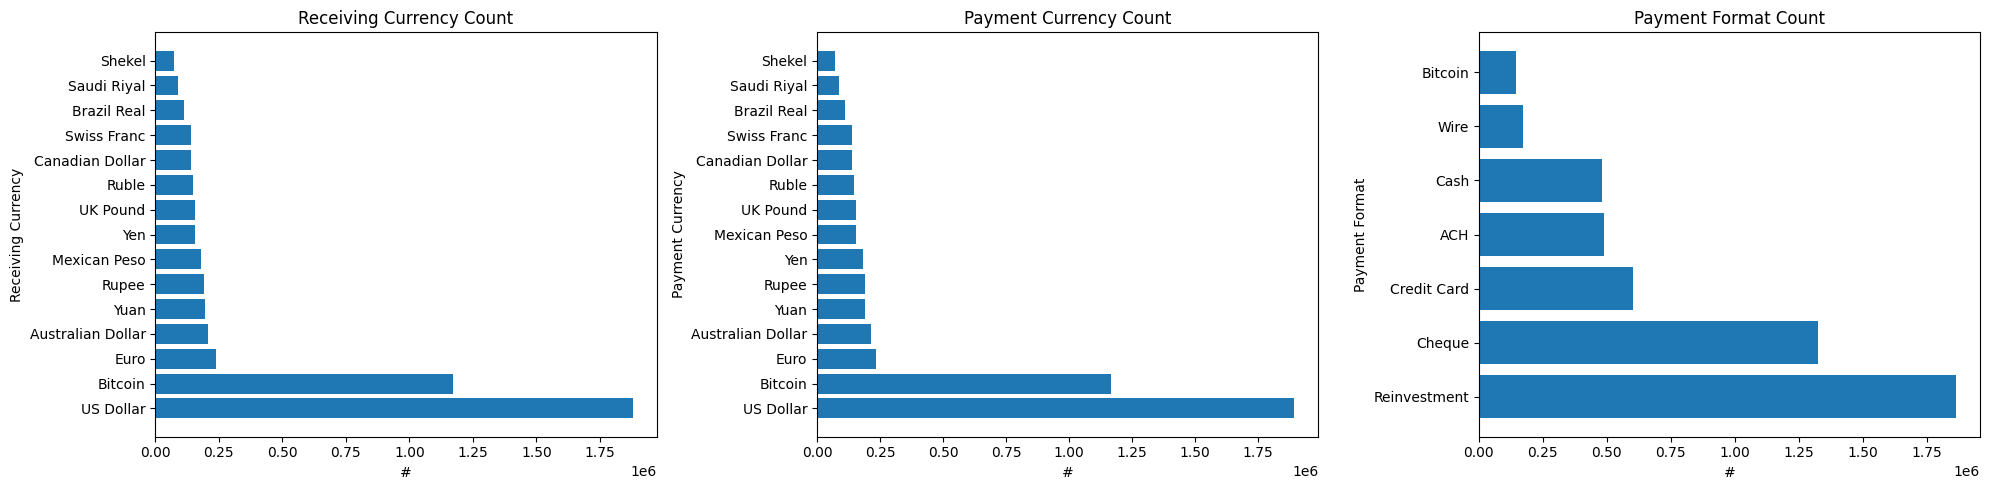

In [28]:
categorical_columns = ["Receiving Currency", "Payment Currency", "Payment Format"]
plt.figure(figsize=(20, 5))

for i, column in enumerate(categorical_columns, start=1):
    plt.subplot(1, len(categorical_columns), i)
    plt.title(f"{column} Count")
    plt.ylabel(column)
    plt.xlabel("#")
    plt.barh(y=transactions[column].unique(), width=transactions[column].value_counts())

plt.tight_layout()
plt.show()

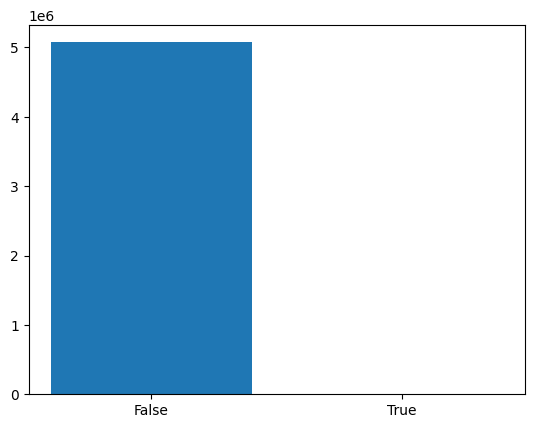

Is Laundering
False    5073168
True        5177
Name: count, dtype: int64


In [29]:
is_laundering = transactions["Is Laundering"].map(lambda x: str(bool(x)))
plt.bar(x=is_laundering.unique(), height=is_laundering.value_counts())
plt.show()
print(is_laundering.value_counts())

In [30]:
numerical_columns = ["Amount Received", "Amount Paid"]

transactions[numerical_columns].describe()

,Amount Received,Amount Paid
count,5.078345e+06,5.078345e+06
mean,5.988726e+06,4.509273e+06
std,1.037183e+09,8.697728e+08
min,1.000000e-06,1.000000e-06
25%,1.833700e+02,1.844800e+02
50%,1.411010e+03,1.414540e+03
75%,1.234627e+04,1.229784e+04
max,1.046302e+12,1.046302e+12


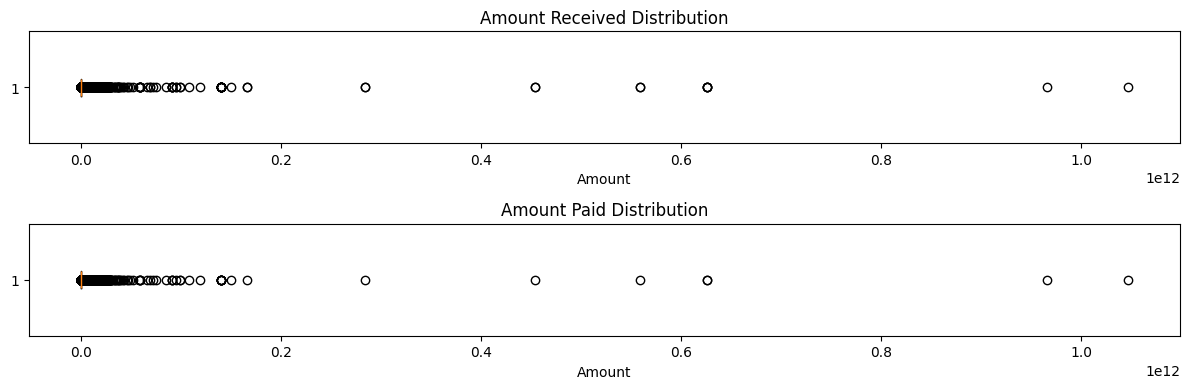

In [31]:
plt.figure(figsize=(12,4))

for i, column in enumerate(transactions[numerical_columns], start=1):
    plt.subplot(len(numerical_columns), 1, i)
    plt.title(f"{column} Distribution")
    plt.xlabel("Amount")
    plt.boxplot(transactions[column], orientation="horizontal")

plt.tight_layout()
plt.show()

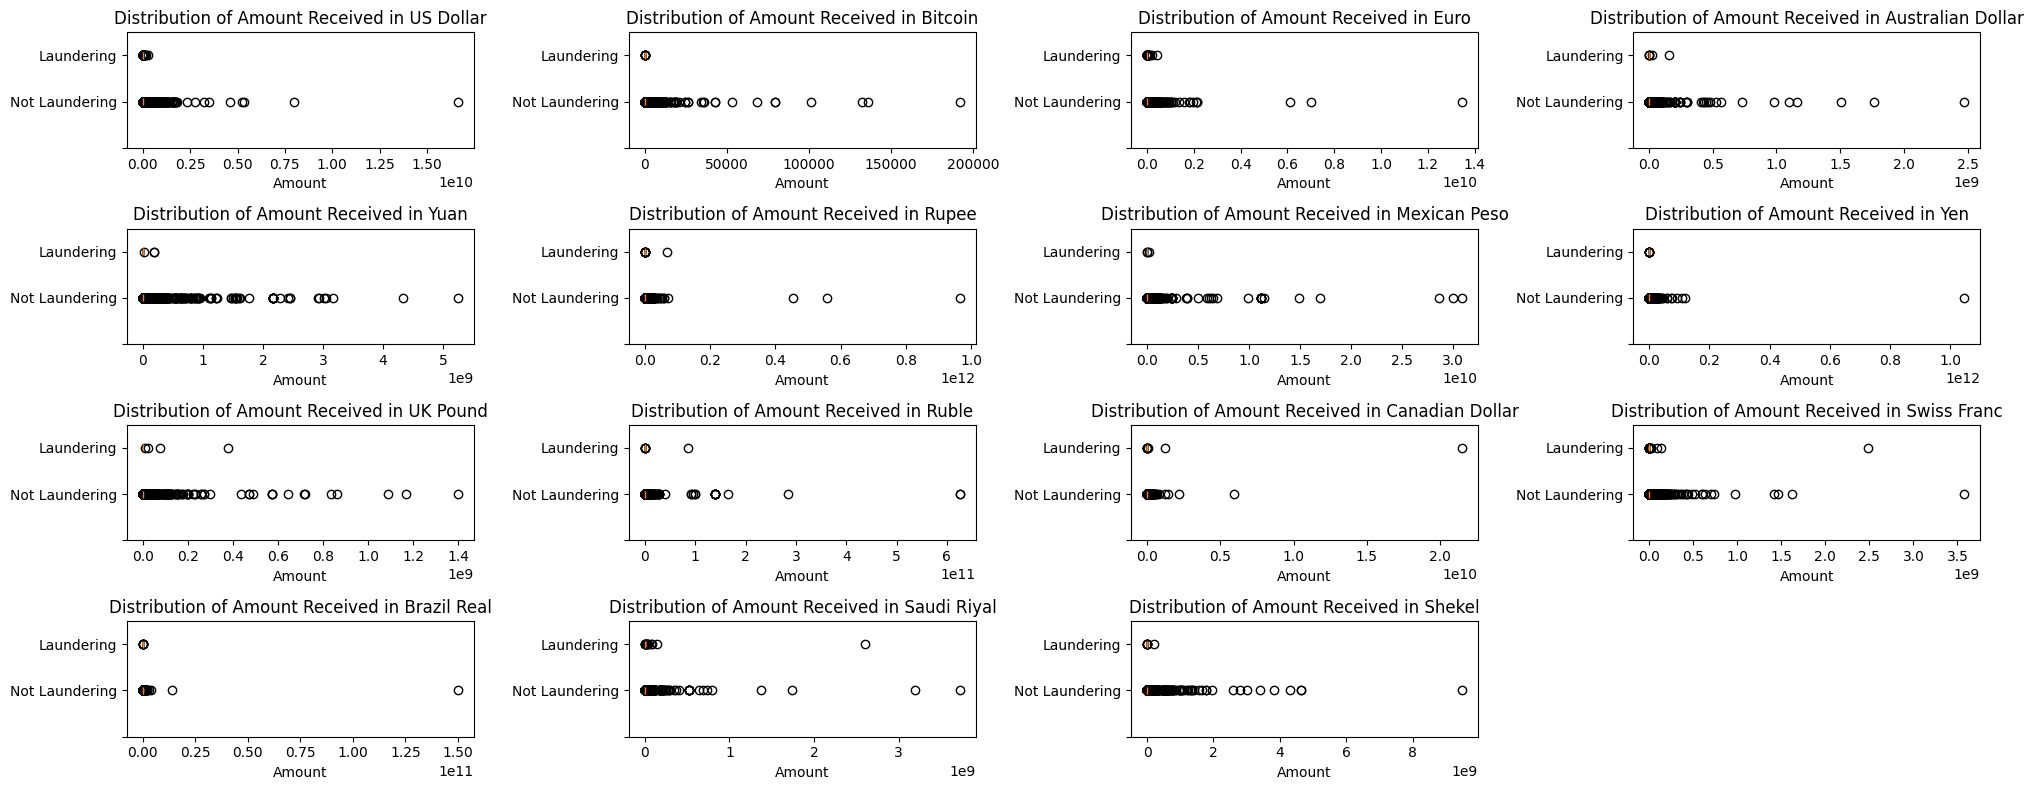

In [32]:
currencies = transactions['Receiving Currency'].unique()
plt.figure(figsize=(20, math.ceil(len(currencies) / 2)))

for i, currency in enumerate(currencies, start=1):
    plt.subplot(math.ceil(len(currencies) / 4), 4, i)
    plt.title(f'Distribution of Amount Received in {currency}')
    plt.xlabel('Amount')
    plt.boxplot(
        [
            transactions[(transactions['Receiving Currency'] == currency) & (transactions['Is Laundering'] == 0)]['Amount Paid'],
            transactions[(transactions['Receiving Currency'] == currency) & (transactions['Is Laundering'] == 1)]['Amount Paid'],
        ], 
        orientation='horizontal',
    )
    plt.yticks(range(3), ["", "Not Laundering", "Laundering"])
    # sns.histplot(transactions[transactions['Receiving Currency'] == currency]['Amount Received'], kde=True)

plt.tight_layout()
plt.show()

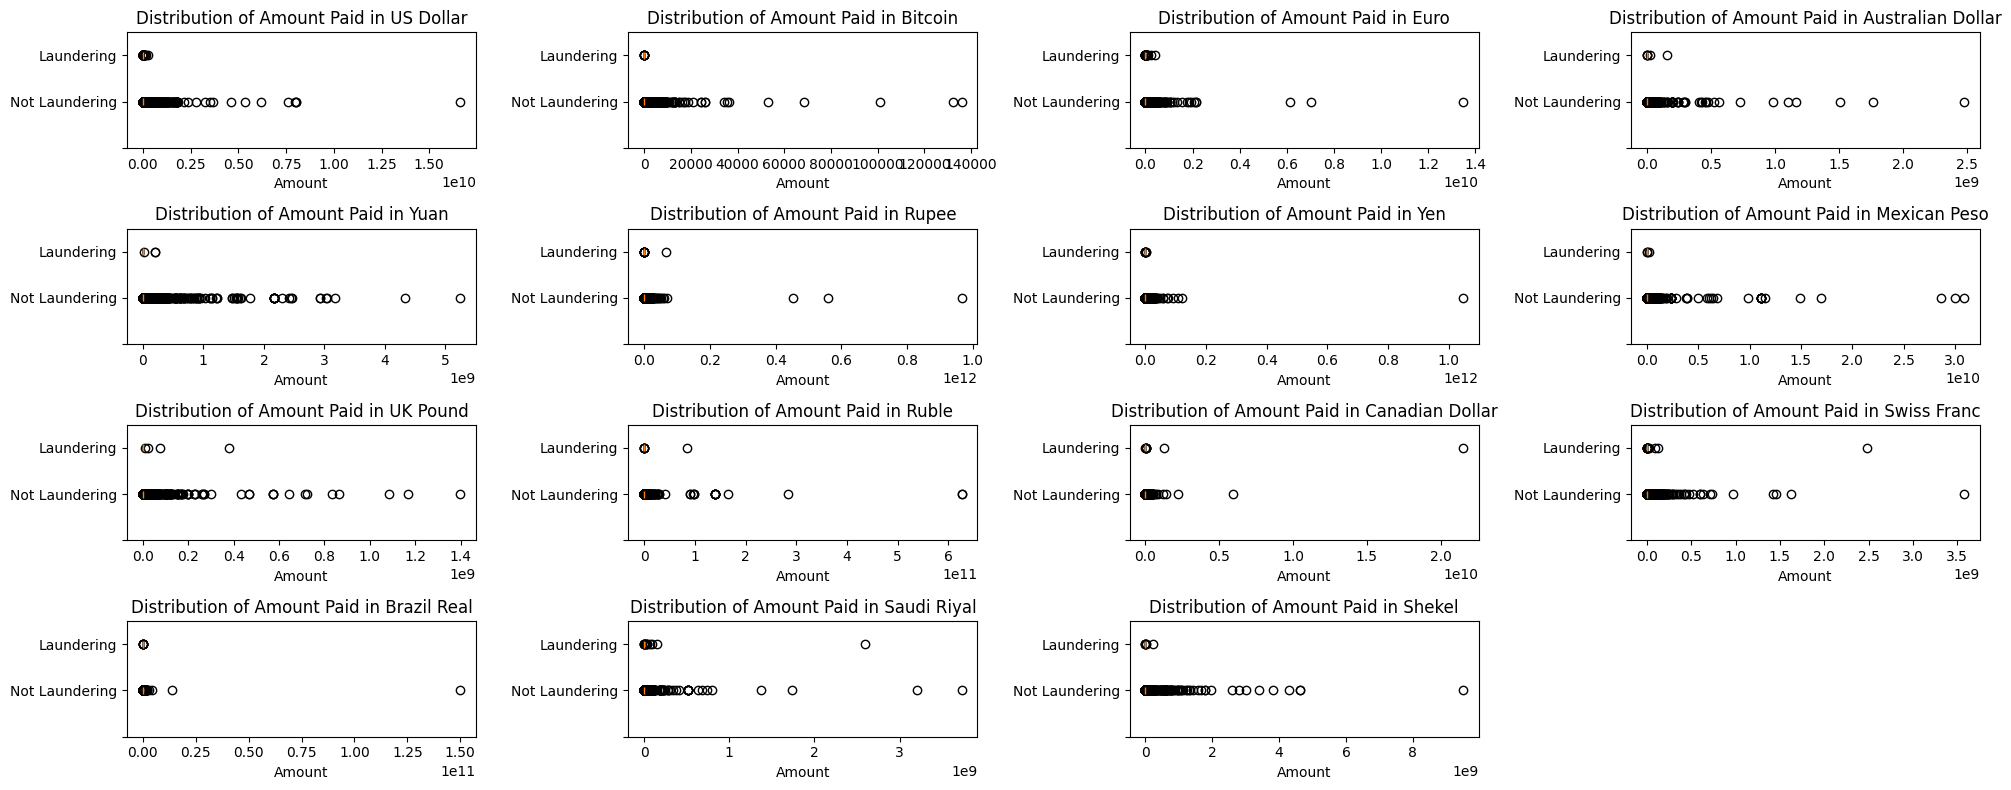

In [33]:
currencies = transactions['Payment Currency'].unique()
plt.figure(figsize=(20, math.ceil(len(currencies) / 2)))

for i, currency in enumerate(currencies, start=1):
    plt.subplot(math.ceil(len(currencies) / 4), 4, i)
    plt.title(f'Distribution of Amount Paid in {currency}')
    plt.xlabel('Amount')
    plt.boxplot(
        [
            transactions[(transactions['Payment Currency'] == currency) & (transactions['Is Laundering'] == 0)]['Amount Paid'],
            transactions[(transactions['Payment Currency'] == currency) & (transactions['Is Laundering'] == 1)]['Amount Paid'],
        ], 
        orientation='horizontal',
    )
    plt.yticks(range(3), ["", "Not Laundering", "Laundering"])
    # sns.histplot(transactions[transactions['Receiving Currency'] == currency]['Amount Received'], kde=True)

plt.tight_layout()
plt.show()

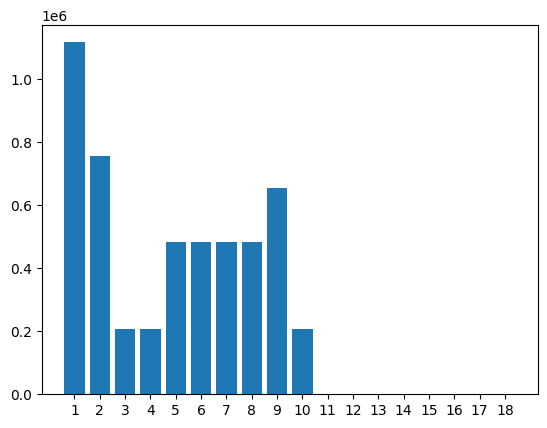

In [34]:
transactions_by_date = transactions['Timestamp'].dt.day.value_counts().sort_index()
x = transactions_by_date.index
y = transactions_by_date.values
plt.bar(x=x, height=y)
# plt.xticks(range(len(transactions_by_date)), labels=transactions_by_date.index)
plt.xticks(x)
plt.show()

# Understand Accounts and Transactions Relationship

In [35]:
accounts.head()

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank,331579,80B779D80,80062E240,Sole Proprietorship
1,Canada Bank,210,809D86900,800C998A0,Corporation
2,UK Bank,21884,80812BE00,800C47F50,Partnership
3,Germany Bank,32742,81047F300,80096F0B0,Corporation
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation


In [36]:
print(f'{transactions.shape=}')
transactions.head()

transactions.shape=(5078345, 11)


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [37]:
pd.merge(
    transactions,
    accounts,
    left_on=['From Account', 'From Bank'],
    right_on=['Account Number', 'Bank ID'],
    how='inner'
).shape

(5078345, 16)

# Data Modelling

In [38]:
import networkx as nx
import torch
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from torch_geometric.data import Data
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.utils import to_networkx

/Users/darrellcr/Devs/apple_aiml/c1/tabular/python/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Vertex (Account)
features:
- bank id
- bank name
- account number
- entity name

Edge (Transaction)
features:
- Amount Received
- Amount Paid
- Receiving Currency
- Payment Currency
- Payment Format

## Vertex

In [39]:
accounts_iterator = accounts.loc[:, ['Bank ID', 'Account Number']].itertuples()

account_to_idx = {(bank, account): i for i, (_, bank, account) in enumerate(accounts_iterator)}

In [40]:
transformer = ColumnTransformer([
    ('categorical_features', OneHotEncoder(sparse_output=False, drop='first'), ['Entity Name'])
], remainder='drop')


vertices = torch.tensor(transformer.fit_transform(accounts), dtype=torch.float)

## Edge

### Connections

In [41]:
transactions.head()

,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [42]:
source_keys = list(zip(transactions['From Bank'], transactions['From Account']))
destination_keys = list(zip(transactions['To Bank'], transactions['To Account']))

transactions['source'] = pd.Series(source_keys).map(account_to_idx)
transactions['destination'] = pd.Series(destination_keys).map(account_to_idx)
transactions.head()

,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,source,destination
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,435512,435512
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,65242,474699
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,65597,65597
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,475408,475408
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,475619,475619


In [43]:
transactions[['source', 'destination']].values.T


array([[435512,  65242,  65597, ..., 460201, 430481, 497197],
       [435512, 474699,  65597, ..., 405368, 405368, 405368]],
      shape=(2, 5078345))

In [44]:
edge_index = torch.tensor(transactions[['source', 'destination']].values.T, dtype=torch.long)

### Features

In [45]:
categorical_features = ['Payment Format', 'Receiving Currency', 'Payment Currency']
numerical_features = ['Amount Received', 'Amount Paid']

transformer = ColumnTransformer([
    ('categorical', OneHotEncoder(sparse_output=False), categorical_features),
    ('numerical', RobustScaler(), numerical_features),
], remainder='passthrough', verbose_feature_names_out=False)

transformer.set_output(transform='pandas')

preprocessed_transactions = transformer.fit_transform(transactions)
to_remove = ['From Bank', 'From Account', 'To Account', 'To Bank', 'Is Laundering', 'Timestamp']
preprocessed_transactions = preprocessed_transactions.drop(columns=to_remove)
preprocessed_transactions.columns

Index(['Payment Format_ACH', 'Payment Format_Bitcoin', 'Payment Format_Cash',
       'Payment Format_Cheque', 'Payment Format_Credit Card',
       'Payment Format_Reinvestment', 'Payment Format_Wire',
       'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin',
       'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar',
       'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso',
       'Receiving Currency_Ruble', 'Receiving Currency_Rupee',
       'Receiving Currency_Saudi Riyal', 'Receiving Currency_Shekel',
       'Receiving Currency_Swiss Franc', 'Receiving Currency_UK Pound',
       'Receiving Currency_US Dollar', 'Receiving Currency_Yen',
       'Receiving Currency_Yuan', 'Payment Currency_Australian Dollar',
       'Payment Currency_Bitcoin', 'Payment Currency_Brazil Real',
       'Payment Currency_Canadian Dollar', 'Payment Currency_Euro',
       'Payment Currency_Mexican Peso', 'Payment Currency_Ruble',
       'Payment Currency_Rupee'

In [46]:
preprocessed_transactions[numerical_features].head()

,Amount Received,Amount Paid
0,0.187976,0.188453
1,-0.116009,-0.116774
2,1.090575,1.094744
3,0.114772,0.114950
4,2.899963,2.911532


In [47]:
preprocessed_transactions.loc[:, ~preprocessed_transactions.columns.isin(numerical_features)]

,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,...,Payment Currency_Rupee,Payment Currency_Saudi Riyal,Payment Currency_Shekel,Payment Currency_Swiss Franc,Payment Currency_UK Pound,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,source,destination
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,435512,435512
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,65242,474699
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,65597,65597
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,475408,475408
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,475619,475619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,228536,405368
5078341,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,162963,405368
5078342,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,460201,405368
5078343,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,430481,405368


In [48]:
preprocessed_transactions.columns.difference(numerical_features, sort=False)

Index(['Payment Format_ACH', 'Payment Format_Bitcoin', 'Payment Format_Cash',
       'Payment Format_Cheque', 'Payment Format_Credit Card',
       'Payment Format_Reinvestment', 'Payment Format_Wire',
       'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin',
       'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar',
       'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso',
       'Receiving Currency_Ruble', 'Receiving Currency_Rupee',
       'Receiving Currency_Saudi Riyal', 'Receiving Currency_Shekel',
       'Receiving Currency_Swiss Franc', 'Receiving Currency_UK Pound',
       'Receiving Currency_US Dollar', 'Receiving Currency_Yen',
       'Receiving Currency_Yuan', 'Payment Currency_Australian Dollar',
       'Payment Currency_Bitcoin', 'Payment Currency_Brazil Real',
       'Payment Currency_Canadian Dollar', 'Payment Currency_Euro',
       'Payment Currency_Mexican Peso', 'Payment Currency_Ruble',
       'Payment Currency_Rupee'

In [49]:
edge_features = torch.tensor(preprocessed_transactions.values, dtype=torch.float)
edge_features[:2]

tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00,
          0.0000e+00,  0.0000e+00,  1.8798e-01,  1.8845e-01,  4.3551e+05,
          4.3551e+05],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.000

### Label

In [50]:
edge_label = transactions['Is Laundering'].values
edge_label

array([0, 0, 0, ..., 0, 0, 0], shape=(5078345,))

## Graph

### Splitting Data

In [51]:
train_cut_off_index = math.floor(transactions.shape[0] * 0.7)
train_cut_off_time = transactions['Timestamp'].sort_values().iloc[train_cut_off_index]
train_edges_index = transactions[transactions['Timestamp'] <= train_cut_off_time].index
train_edges_mask = transactions.index.isin(train_edges_index)
print(f'train proportion: {train_edges_mask.sum() / transactions.shape[0]}')

train proportion: 0.7000227436300606


In [52]:
validation_cut_off_index = train_cut_off_index + math.floor(transactions.shape[0] * 0.15)
validation_cut_off_time = transactions['Timestamp'].sort_values().iloc[validation_cut_off_index]
validation_edges_index = transactions[(transactions['Timestamp'] <= validation_cut_off_time) & (transactions['Timestamp'] > train_cut_off_time)].index
validation_edges_mask = transactions.index.isin(validation_edges_index)
print(f'validation proportion: {validation_edges_mask.sum() / transactions.shape[0]}')

validation proportion: 0.14999945848499857


In [53]:
test_edges_index = transactions[transactions['Timestamp'] > validation_cut_off_time].index
test_edges_mask = transactions.index.isin(test_edges_index)
print(f'test proportion: {test_edges_mask.sum() / transactions.shape[0]}')

test proportion: 0.14997779788494087


In [54]:
(train_edges_mask.sum() + validation_edges_mask.sum() + test_edges_mask.sum()) / transactions.shape[0]

np.float64(1.0)

In [55]:
(transactions['Timestamp'].astype('int64') // 10**9).iloc[train_edges_mask]

0          1661991
1          1661991
2          1661990
3          1661990
4          1661990
            ...   
3557361    1662562
3557362    1662561
3557366    1662562
3557367    1662562
3557368    1662562
Name: Timestamp, Length: 3554957, dtype: int64

In [56]:
train_edge_label = torch.tensor(transactions.iloc[train_edges_mask]['Is Laundering'].values)
unix_timestamp = transactions['Timestamp'].astype('int64') // 10**9
train_transactions_time = torch.tensor(unix_timestamp.iloc[train_edges_mask].values, dtype=torch.long)

In [64]:
data = Data(x=vertices, edge_index=edge_index, edge_attr=edge_features)
data.edge_time = torch.tensor(unix_timestamp.values)
indices = torch.tensor(train_edges_index, dtype=torch.long)
edge_label_index = data.edge_index[:, indices]
loader = LinkNeighborLoader(
    data,
    num_neighbors=[10, 5],
    batch_size=128,
    edge_label_index=edge_label_index,
    edge_label=train_edge_label,
    edge_label_time=train_transactions_time,
    time_attr='edge_time',
    shuffle=True,
)

In [67]:
next(iter(loader)).x.shape

torch.Size([1273, 5])

# Model

In [83]:
import random
from time import perf_counter

import numpy as np
import torch
from torch_geometric.nn import GCN

In [80]:
class EdgeClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        out_channels = 32
        self.backbone = GCN(
            in_channels=5,
            hidden_channels=hidden_channels,
            num_layers=3,
            out_channels=hidden_channels,
        )
        self.classifier = torch.nn.Linear(2 * hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_label_index):
        h = self.backbone(x, edge_index)

        row, col = edge_label_index

        edge_features = torch.cat([h[row], h[col]], dim=-1)

        return self.classifier(edge_features)

# Training

In [81]:
def set_seed(seed) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.seed(seed)
    torch.mps.manual_seed(seed)
    torch.use_deterministic_algorithms(True)

In [ ]:
class Trainer:
    def __init__(
        model: torch.nn.Module,
        data_loader,
        Optimizer: type[torch.optim.Optimizer],
    ) -> None:
        self.device = 'mps' if torch.mps.is_available() else 'cpu'
        
        self.model = model.to(self.device)
        self.data_loader = data_loader
        self.optimizer = Optimizer(
            model.parameters(),
            lr=0.01,
            weight_decay=5e-4
        )

        self.epochs_run = 0

    def _run_batch(self, source, targets) -> None:
        self.optimizer.zero_grad()

        logits = 

        loss.backward()
        self.optimizer.step()

    def _run_epoch(self, epoch):
        pass

    @torch.no_grad()
    def _evaluate(self, epoch):
        pass

    def train(self, max_epochs: int) -> None:
        for epoch in range(self.epochs_run, max_epochs):
            self.model.train()
            start_time = perf_counter()
            self._run_epoch(epoch)
            end_time = perf_counter()
            time_elapsed = end_time - start_time

            # loss
            
            print(f'Epoch {epoch} | Time elapsed {time_elapsed:.2f}s')

            self.model.eval()
            self._evaluate(epoch)
            
    

In [ ]:
model = EdgeClassifier(in_channels=5, hidden_channels=65, num_classes=3)
Optimizer = torch.optim.Adam


In [88]:
next(iter(loader))

Data(x=[2, 5], edge_index=[2, 0], edge_attr=[0, 41], edge_time=[0], n_id=[2], e_id=[0], batch=[2], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[1], edge_label_index=[2, 1], edge_label=[1], edge_label_time=[1])